In [37]:
import numpy as np
import matplotlib.pyplot as plt

## LinearRegression Class

In [38]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
        self.gamma = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.theta = None
        self.cost_history = []

    def _compute_mse(self, X, y):
        n = len(y)
        y_hat = np.dot(X, self.theta)
        mse = (1 / (2 * n)) * np.sum((y_hat - y) ** 2)
        return mse

    def fit(self, X, y):
        n, d = X.shape
        X_b = np.c_[np.ones((n, 1)), X] 
        self.theta = np.random.randn(d + 1, 1)
        y = y.reshape(-1, 1)
        prev_mse = float('inf')

        for i in range(self.max_iterations):
            # Step 1: Forward Pass 
            y_hat = np.dot(X_b, self.theta) # h_theta(X) = Y_hat
            error = y_hat - y             # e = Y_hat - Y
            
            # Step 2: Backward Pass (Gradient Calculation)
            # gradient = (1/n) * X^T * e
            gradient = (1 / n) * np.dot(X_b.T, error)
            
            # Step 3: Weights Update
            # theta = theta - gamma * gradient
            self.theta = self.theta - (self.gamma * gradient)
            
            # Step 4: Compute and Store Cost (MSE)
            current_mse = self._compute_mse(X_b, y)
            self.cost_history.append(current_mse)
            
            # Check for convergence
            if abs(prev_mse - current_mse) < self.tolerance:
                print(f"Convergence at iteration {i+1}")
                break
                
            prev_mse = current_mse

    def predict(self, X):
        if self.theta is None:
            raise Exception("Model is not trained yet. Call fit() before predict().")
            
        n = X.shape[0]
        X_b = np.c_[np.ones((n, 1)), X]
        return np.dot(X_b, self.theta)

## Entrenamiento y Visualización

In [39]:
# 1. Mock Dataset Creation
np.random.seed(42)
X_dummy = 2 * np.random.rand(100, 2)

# y ≈ 3*x1 + 5*x2 + 10  + noise
y_dummy = 10 + 3 * X_dummy[:, 0] + 5 * X_dummy[:, 1] + np.random.randn(100)

print("\n--- Real Weights (Theta) ---")
print(f"Intercept (theta_0): {10:.4f}")
print(f"Weight 1 (theta_1):  {3:.4f}")
print(f"Weight 2 (theta_2):  {5:.4f}")


--- Real Weights (Theta) ---
Intercept (theta_0): 10.0000
Weight 1 (theta_1):  3.0000
Weight 2 (theta_2):  5.0000


In [40]:
# 2. Model Training
model = LinearRegression(learning_rate=0.1, max_iterations=1000)
model.fit(X_dummy, y_dummy)

print("\n--- Final Cost (MSE): {:.4f} ---\n".format(model.cost_history[-1]))

print("\n--- Learned Weights (Theta) ---")
print(f"Intercept (theta_0): {model.theta[0][0]:.4f}")
print(f"Weight 1 (theta_1):  {model.theta[1][0]:.4f}")
print(f"Weight 2 (theta_2):  {model.theta[2][0]:.4f}")

Convergence at iteration 426

--- Final Cost (MSE): 0.4907 ---


--- Learned Weights (Theta) ---
Intercept (theta_0): 9.7479
Weight 1 (theta_1):  3.1795
Weight 2 (theta_2):  5.1898


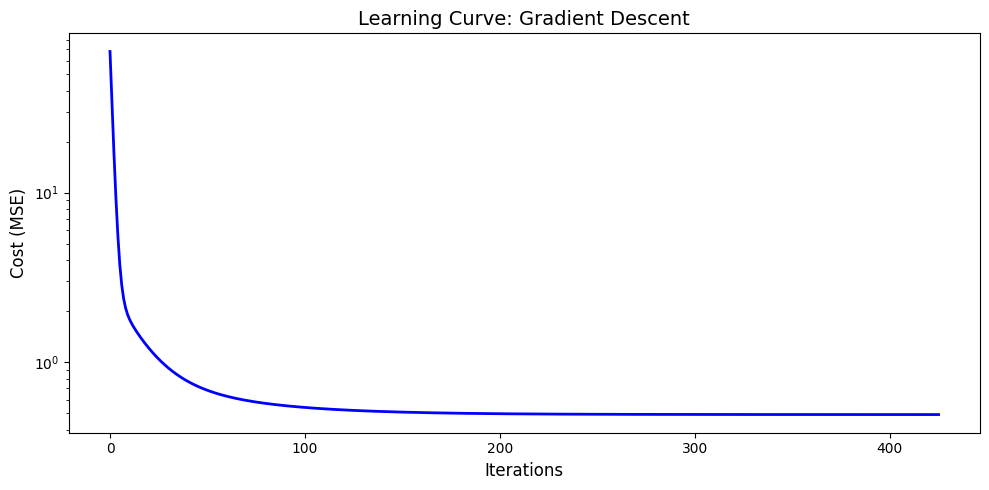

In [41]:
# 3. Learning Curve Visualization
plt.figure(figsize=(10, 5))
plt.plot(model.cost_history, color='blue', linewidth=2)
plt.title('Learning Curve: Gradient Descent', fontsize=14)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Cost (MSE)', fontsize=12)
plt.yscale('log') # Logarithmic scale for better visualization of initial decline
plt.tight_layout()
plt.show()

In [42]:
# 4. Model Prediction
sample_house = np.array([[1.5, 2.0]])
prediction = model.predict(sample_house)
print(f"\nPredicted price for house with features {sample_house[0]}: {prediction[0][0]:.4f}")
print(f"\nReal price for house with features {sample_house[0]}: {10 + 3*sample_house[0][0] + 5*sample_house[0][1]:.4f}")


Predicted price for house with features [1.5 2. ]: 24.8968

Real price for house with features [1.5 2. ]: 24.5000
